# Phân loại ảnh cháy rừng bằng học máy

Notebook đồ án theo 10 mục của giảng viên. Bốn mô hình: Logistic Regression, KNN, SVM, Random Forest. Dữ liệu DeepFire 1.900 ảnh theo nguồn công bố. Các số đo bên dưới lấy từ chạy thực nghiệm, không phải số minh họa.

**Cách chạy:** Colab → Upload notebook → Run all. GPU không bắt buộc. Lần đầu tự tải khoảng 149 MB. Notebook có toàn bộ mã, không cần tải thêm script.

**Phạm vi:** phân loại cả ảnh Fire/No Fire, chưa khoanh vùng hoặc dự báo cháy tương lai.

## 1. Tóm tắt và thiết lập
Mục tiêu: tìm mô hình có F1 lớp cháy tốt trên validation; báo cáo cả Precision và Recall để thấy báo nhầm và bỏ sót. Test được giữ để đánh giá sau khi khóa lựa chọn.

In [1]:
import sys, subprocess, importlib.util, os
from pathlib import Path
cwd = Path.cwd()
if cwd.name == 'notebooks' and (cwd.parent/'src/experiment.py').exists():
    PROJECT_DIR = cwd.parent
elif (cwd/'src/experiment.py').exists():
    PROJECT_DIR = cwd
else:
    PROJECT_DIR = cwd/'MayHoc'
PROJECT_DIR.mkdir(exist_ok=True)
packages={'sklearn':'scikit-learn==1.7.2','skimage':'scikit-image==0.25.2','matplotlib':'matplotlib==3.10.6','pandas':'pandas>=2.2','PIL':'Pillow>=10.1','joblib':'joblib'}
missing=[p for m,p in packages.items() if importlib.util.find_spec(m) is None]
if missing: subprocess.check_call([sys.executable,'-m','pip','install',*missing])
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
print('Thư mục:',PROJECT_DIR)


Thư mục: C:\Users\Admin\Desktop\Hosonhaphoc\6-Xử lí Ngôn ngữ Tự nhiên\Doan\MayHoc


## 2. Giới thiệu dataset
Nguồn: https://www.kaggle.com/datasets/alik05/forest-fire-dataset (CC BY 4.0). Dataset card công bố 950 ảnh mỗi lớp, RGB 250×250. Kho tải gồm Training và Testing. Nhãn đọc từ tên tệp `fire_...` và `nofire_...`; đây là sử dụng nhãn nguồn, không phải mô hình tự gán nhãn.

Giữ Testing; loại trùng pixel và kiểm tra nhóm dHash khoảng cách ≤4. Loại train gần test, tách validation bằng nhóm để giảm rò rỉ. Chưa có mã vụ cháy/địa điểm nên không tuyên bố độc lập hoàn toàn theo sự kiện.

### Mã nguồn đầy đủ
Các hàm bên dưới thực hiện kiểm tra dữ liệu, EDA, đặc trưng, tìm tham số và đánh giá. StandardScaler và PCA nằm trong Pipeline, chỉ được học trên phần train của mỗi fold.

In [2]:
"""DeepFire: audit images, EDA, four classical ML models, held-out evaluation.

Run from MayHoc: python src/experiment.py --download
Source labels and test split are preserved. Near-duplicate groups never cross
train/validation/test. All learned transformations live inside CV pipelines.
"""
from pathlib import Path
import argparse, hashlib, json, os, platform, time, urllib.request, zipfile
import warnings
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from skimage.color import rgb2hsv, rgb2gray
from skimage.feature import hog
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from joblib import Memory, dump
from threadpoolctl import threadpool_limits
import sklearn, skimage

ROOT = PROJECT_DIR
SOURCE = 'https://www.kaggle.com/datasets/alik05/forest-fire-dataset'
DOWNLOAD = 'https://www.kaggle.com/api/v1/datasets/download/alik05/forest-fire-dataset'
SEED = 42
LABELS = ['Không cháy', 'Cháy']
SIZE = 96
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def save_json(path, value):
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding='utf-8')

def prepare_data(download=False):
    for d in ['data/raw', 'results', 'reports/figures', 'models', '.cache']:
        (ROOT/d).mkdir(parents=True, exist_ok=True)
    if list((ROOT/'data/raw').rglob('*.jpg')):
        return
    archive = ROOT/'data/forest-fire-dataset.zip'
    if not archive.exists():
        if not download:
            raise FileNotFoundError('Chưa có dữ liệu. Chạy với --download hoặc đặt ZIP trong data/.')
        print('Downloading public DeepFire dataset...', flush=True)
        urllib.request.urlretrieve(DOWNLOAD, archive)
    with zipfile.ZipFile(archive) as z:
        root = (ROOT/'data/raw').resolve()
        for name in z.namelist():
            if not (root/name).resolve().is_relative_to(root):
                raise ValueError('Unsafe archive path')
        z.extractall(root)

def load_rgb(path):
    with Image.open(path) as im:
        return ImageOps.exif_transpose(im).convert('RGB')

def dhash(im):
    a = np.asarray(im.convert('L').resize((9,8)), dtype=np.int16)
    bits = a[:,1:] > a[:,:-1]
    return sum(int(x)<<i for i,x in enumerate(bits.ravel()))



In [3]:
def audit_data():
    records, bad = [], []
    for path in sorted((ROOT/'data/raw').rglob('*')):
        if path.suffix.lower() not in {'.jpg','.jpeg','.png'}:
            continue
        name = path.name.lower()
        label = 0 if name.startswith('nofire') else 1 if name.startswith('fire') else None
        if label is None:
            raise ValueError(f'Unknown label: {path}')
        try:
            im = load_rgb(path)
            a = np.asarray(im)
            gray = np.asarray(im.convert('L').resize((96,96)), dtype=float)
            sharpness = np.var(gray[1:-1,:-2]+gray[1:-1,2:]+gray[:-2,1:-1]+gray[2:,1:-1]-4*gray[1:-1,1:-1])
            records.append(dict(path=path.relative_to(ROOT).as_posix(), label=label,
                source_split='test' if 'Testing' in path.parts else 'train',
                width=im.width, height=im.height,
                pixel_sha256=hashlib.sha256(str(im.size).encode()+a.tobytes()).hexdigest(),
                dhash=f'{dhash(im):016x}', brightness=float(gray.mean()/255),
                sharpness=float(sharpness)))
        except (OSError, ValueError) as ex:
            bad.append({'path':str(path.relative_to(ROOT)), 'reason':str(ex)})
    df = pd.DataFrame(records)
    if not len(df):
        raise RuntimeError('No readable images')
    raw_counts = df.groupby(['source_split','label']).size().to_dict()
    # Keep official test copy when an identical image also occurs in training.
    df = df.sort_values(['source_split','path']).reset_index(drop=True)
    duplicate = df.duplicated('pixel_sha256', keep='first')
    dropped_exact = df[duplicate].copy()
    df = df[~duplicate].reset_index(drop=True)
    # dHash is a conservative candidate grouping heuristic, not proof of same event.
    parent = list(range(len(df)))
    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]; i = parent[i]
        return i
    hashes = [int(h,16) for h in df.dhash]
    near_pairs = []
    for i in range(len(df)):
        for j in range(i):
            dist = (hashes[i]^hashes[j]).bit_count()
            if dist <= 4:
                a,b = find(i),find(j)
                if a != b: parent[a] = b
                near_pairs.append({'a':df.iloc[i].path,'b':df.iloc[j].path,'distance':dist})
    df['group'] = [find(i) for i in range(len(df))]
    # A group with conflicting source labels is excluded; never silently relabel.
    conflicts = set(df.groupby('group').label.nunique().loc[lambda x:x>1].index)
    dropped_conflict = df[df.group.isin(conflicts)].copy()
    df = df[~df.group.isin(conflicts)].copy()
    test_groups = set(df.loc[df.source_split=='test','group'])
    leakage = (df.source_split=='train') & df.group.isin(test_groups)
    dropped_near = df[leakage].copy()
    df = df[~leakage].reset_index(drop=True)
    pool = df[df.source_split=='train']
    splitter = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED)
    tr,va = next(splitter.split(pool, pool.label, pool.group))
    df['split'] = 'test'
    df.loc[pool.iloc[tr].index,'split'] = 'train'
    df.loc[pool.iloc[va].index,'split'] = 'validation'
    groups = {s:set(df.loc[df.split==s,'group']) for s in ['train','validation','test']}
    assert not (groups['train']&groups['validation'] or groups['train']&groups['test'] or groups['validation']&groups['test'])
    assert all(df.loc[df.split==s,'label'].nunique()==2 for s in groups)
    df.to_csv(ROOT/'results/data_manifest.csv',index=False)
    for title,frame in [('excluded_exact_duplicates',dropped_exact),('excluded_conflicting_groups',dropped_conflict),('excluded_train_near_test',dropped_near)]:
        frame.to_csv(ROOT/f'results/{title}.csv',index=False)
    pd.DataFrame(near_pairs,columns=['a','b','distance']).to_csv(ROOT/'results/near_duplicate_pairs.csv',index=False)
    save_json(ROOT/'results/unreadable_images.json',bad)
    counts = pd.crosstab(df.split,df.label).reindex(['train','validation','test']).rename(columns={0:'non_fire',1:'fire'})
    counts['total'] = counts.sum(axis=1)
    counts.to_csv(ROOT/'results/split_counts.csv')
    info = dict(source=SOURCE,download=DOWNLOAD,license='CC BY 4.0 (dataset card)',
                original_readable=len(records),unreadable=len(bad),
                source_counts={f'{k[0]}_{k[1]}':int(v) for k,v in raw_counts.items()},
                exact_duplicates_removed=len(dropped_exact),conflict_images_removed=len(dropped_conflict),
                train_images_near_test_removed=len(dropped_near),retained=len(df),
                near_pair_count=len(near_pairs),split_counts=counts.to_dict('index'),
                grouping='64-bit dHash distance <= 4, connected components',seed=SEED)
    archive=ROOT/'data/forest-fire-dataset.zip'
    info['archive_sha256']=hashlib.sha256(archive.read_bytes()).hexdigest() if archive.exists() else None
    save_json(ROOT/'results/dataset_audit.json',info)
    return df,info



In [4]:
def figsave(name):
    plt.tight_layout()
    plt.savefig(ROOT/f'reports/figures/{name}.png',dpi=150,bbox_inches='tight')
    plt.close()

def sample_grid(frame,name,title,n=8):
    rows=2; cols=4
    fig,axes=plt.subplots(rows,cols,figsize=(11,5.6))
    samples=frame.head(n)
    for ax,(_,r) in zip(axes.ravel(),samples.iterrows()):
        ax.imshow(load_rgb(ROOT/r.path)); ax.set_title(r.get('caption',f'{LABELS[int(r.label)]} · {Path(r.path).name}'),fontsize=9)
    for ax in axes.ravel(): ax.axis('off')
    fig.suptitle(title,fontsize=14)
    figsave(name)

def eda(df):
    counts=pd.crosstab(df.split,df.label).reindex(['train','validation','test'])
    counts.columns=LABELS
    counts.plot.bar(figsize=(8,4),color=['#287D63','#D86B35'],rot=0)
    plt.ylabel('Số ảnh');plt.xlabel('Tập dữ liệu');plt.title('Phân bố hai lớp sau kiểm tra dữ liệu')
    figsave('01_class_distribution')
    train=df[df.split=='train']
    samples=pd.concat([train[train.label==i].sample(min(4,sum(train.label==i)),random_state=42) for i in [0,1]])
    sample_grid(samples,'02_samples','Ảnh mẫu từ tập train')
    fig,axes=plt.subplots(1,3,figsize=(12,3.8))
    for i in [0,1]:
        sub=train[train.label==i]
        axes[0].scatter(sub.width,sub.height,label=LABELS[i],alpha=.5)
        axes[1].hist(sub.brightness,bins=20,alpha=.5,label=LABELS[i])
        axes[2].hist(np.log1p(sub.sharpness),bins=20,alpha=.5,label=LABELS[i])
    for ax in axes:ax.legend(fontsize=8)
    axes[0].set(xlabel='Chiều rộng',ylabel='Chiều cao',title='Kích thước ảnh')
    axes[1].set(xlabel='Độ sáng trung bình [0,1]',title='Độ sáng')
    axes[2].set(xlabel='log(1 + phương sai Laplacian)',title='Chỉ báo độ sắc nét')
    figsave('03_quality')
    fig,axes=plt.subplots(1,2,figsize=(10,3.8))
    means=[]
    for label in [0,1]:
        images=[np.asarray(load_rgb(ROOT/r.path).resize((SIZE,SIZE)),dtype=np.float32)/255 for r in train[train.label==label].itertuples()]
        mean=np.mean(images,axis=0);means.append(mean)
        hh=np.mean([np.histogram(rgb2hsv(a)[:,:,0],bins=32,range=(0,1),density=False)[0]/(SIZE*SIZE) for a in images],axis=0)
        axes[0].plot(np.linspace(0,360,32,endpoint=False),hh,label=LABELS[label])
    axes[0].set(xlabel='Hue (độ)',ylabel='Tỷ lệ pixel',title='Phân bố Hue trung bình trên train');axes[0].legend()
    rgbmeans=np.array([m.mean(axis=(0,1)) for m in means])
    for i in [0,1]:axes[1].bar(np.arange(3)+(i-.5)*.32,rgbmeans[i],width=.32,label=LABELS[i])
    axes[1].set_xticks(range(3),['R','G','B']);axes[1].set_title('Cường độ RGB trung bình');axes[1].legend()
    figsave('04_color')
    fig,axes=plt.subplots(1,2,figsize=(7,3.6))
    for i in [0,1]:axes[i].imshow(means[i]);axes[i].set_title(LABELS[i]);axes[i].axis('off')
    figsave('05_mean_images')
    return {'mean_rgb_train':rgbmeans.tolist(),'train_brightness_by_class':train.groupby('label').brightness.mean().to_dict()}



In [5]:
def feature(path):
    rgb=np.asarray(load_rgb(path).resize((SIZE,SIZE)),dtype=np.float32)/255
    hsv=rgb2hsv(rgb)
    color=np.concatenate([np.histogram(hsv[:,:,c],bins=b,range=(0,1))[0]/(SIZE*SIZE) for c,b in enumerate([32,16,16])])
    shape=hog(rgb2gray(rgb),orientations=8,pixels_per_cell=(16,16),cells_per_block=(2,2),block_norm='L2-Hys')
    return np.r_[color,shape].astype(np.float32)

def scores(y,p):
    return dict(accuracy=float(accuracy_score(y,p)),precision=float(precision_score(y,p,zero_division=0)),
                recall=float(recall_score(y,p,zero_division=0)),f1=float(f1_score(y,p,zero_division=0)),
                macro_f1=float(f1_score(y,p,average='macro',zero_division=0)))



In [6]:
def run(download=False):
    start=time.perf_counter();prepare_data(download)
    df,audit=audit_data();print('Audit:',audit,flush=True)
    edainfo=eda(df)
    X=np.vstack([feature(ROOT/p) for p in df.path]);y=df.label.to_numpy()
    np.savez_compressed(ROOT/'results/features.npz',X=X,y=y)
    masks={s:(df.split==s).to_numpy() for s in ['train','validation','test']}
    tr,va,te=[masks[s] for s in ['train','validation','test']]
    cv=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=SEED)
    folds=list(cv.split(X[tr],y[tr],df.loc[tr,'group']))
    mem=Memory(ROOT/'.cache/pipeline',verbose=0)
    configs={
      'Logistic Regression':(LogisticRegression(max_iter=3000,random_state=SEED),{'model__C':[.1,1,10]}),
      'KNN':(KNeighborsClassifier(),{'model__n_neighbors':[3,5,9],'model__weights':['uniform','distance']}),
      'SVM':(SVC(random_state=SEED),{'model__C':[1,10],'model__kernel':['linear','rbf']}),
      'Random Forest':(RandomForestClassifier(n_estimators=150,random_state=SEED,n_jobs=2),{'model__max_depth':[12,None],'model__min_samples_leaf':[1,2]})}
    rows=[];models={};params={};reports={};cms={};preds=df[['path','label','split','group','brightness','sharpness']].copy()
    for name,(model,grid) in configs.items():
        print('Training',name,flush=True);t=time.perf_counter()
        pipe=Pipeline([('scale',StandardScaler()),('pca',PCA(n_components=.95,svd_solver='full')),('model',model)],memory=mem)
        search=GridSearchCV(pipe,grid,cv=folds,scoring={'f1':'f1','recall':'recall','accuracy':'accuracy'},refit='f1',n_jobs=1,error_score='raise',return_train_score=True)
        search.fit(X[tr],y[tr]);best=search.best_estimator_;models[name]=best
        elapsed=time.perf_counter()-t
        pd.DataFrame(search.cv_results_).to_csv(ROOT/f'results/cv_{name.replace(" ","_")}.csv',index=False)
        row={'model':name,'cv_f1':float(search.best_score_),'cv_f1_std':float(search.cv_results_['std_test_f1'][search.best_index_]),'search_seconds':elapsed,'pca_components':int(best.named_steps['pca'].n_components_)}
        for split in ['train','validation']:
            m=masks[split];pr=best.predict(X[m]);row.update({f'{split}_{k}':v for k,v in scores(y[m],pr).items()})
        rows.append(row);params[name]=search.best_params_
    # Model choice is locked using validation only, before any test predictions.
    winner=sorted(rows,key=lambda r:(r['validation_f1'],r['validation_recall']),reverse=True)[0]['model']
    save_json(ROOT/'results/selection_before_test.json',{'selected_model':winner,'criterion':'Highest validation F1, then validation recall','rows':rows,'params':params})
    print('Selected using validation:',winner,flush=True)
    for row in rows:
        name=row['model'];best=models[name];tp=best.predict(X[te]);allp=best.predict(X)
        row.update({f'test_{k}':v for k,v in scores(y[te],tp).items()})
        timings=[]
        for _ in range(5):
            t=time.perf_counter();best.predict(X[te]);timings.append((time.perf_counter()-t)*1000/te.sum())
        row['predict_ms_per_image']=float(np.median(timings))
        cms[name]=confusion_matrix(y[te],tp,labels=[0,1]).tolist()
        reports[name]=classification_report(y[te],tp,target_names=LABELS,output_dict=True,zero_division=0)
        preds[name]=allp;dump(best,ROOT/f'models/{name.replace(" ","_")}.joblib')
    results=pd.DataFrame(rows);results.to_csv(ROOT/'results/model_metrics.csv',index=False)
    preds.to_csv(ROOT/'results/predictions.csv',index=False)
    save_json(ROOT/'results/classification_reports.json',reports);save_json(ROOT/'results/confusion_matrices.json',cms)
    dummy=DummyClassifier(strategy='most_frequent').fit(X[tr],y[tr]);baseline=scores(y[te],dummy.predict(X[te]))
    fig,axes=plt.subplots(2,2,figsize=(9,7))
    for ax,(name,cm) in zip(axes.ravel(),cms.items()):
        cm=np.array(cm);ax.imshow(cm,cmap='Blues',vmin=0,vmax=cm.max())
        for i in [0,1]:
            for j in [0,1]:ax.text(j,i,str(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black',fontsize=17)
        ax.set(xticks=[0,1],yticks=[0,1],xticklabels=LABELS,yticklabels=LABELS,xlabel='Dự đoán',ylabel='Nhãn thật',title=name)
    figsave('06_confusion_matrices')
    fig,axes=plt.subplots(1,2,figsize=(12,4.2))
    for ax,cols,title in [(axes[0],['test_accuracy','test_f1','test_recall'],'Kết quả trên tập test'),(axes[1],['train_f1','validation_f1'],'Train và validation')]:
        results.set_index('model')[cols].plot.bar(ax=ax,rot=12);ax.set_ylim(0,1.05);ax.set_title(title);ax.set_xlabel('');ax.set_ylabel('Điểm [0,1]');ax.legend(fontsize=8)
    figsave('07_model_comparison')
    # Learning curve uses only train and the same grouped cross-validation splits.
    sizes,train_sc,valid_sc=learning_curve(models[winner],X[tr],y[tr],cv=folds,train_sizes=[.35,.65,1.0],scoring='f1',n_jobs=1,shuffle=True,random_state=SEED,error_score='raise')
    curve=pd.DataFrame({'n_train':sizes,'train_f1_mean':train_sc.mean(axis=1),'train_f1_std':train_sc.std(axis=1),'cv_f1_mean':valid_sc.mean(axis=1),'cv_f1_std':valid_sc.std(axis=1)})
    curve.to_csv(ROOT/'results/learning_curve.csv',index=False)
    plt.figure(figsize=(7,4));plt.errorbar(sizes,train_sc.mean(axis=1),yerr=train_sc.std(axis=1),marker='o',label='Train');plt.errorbar(sizes,valid_sc.mean(axis=1),yerr=valid_sc.std(axis=1),marker='o',label='CV trên train');plt.ylim(0,1.05);plt.xlabel('Số ảnh học trong mỗi fold');plt.ylabel('F1 lớp cháy');plt.title('Đường học của '+winner);plt.legend();figsave('08_learning_curve')
    test=preds[te].copy();test['error_type']=np.where(test.label==test[winner],'Đúng',np.where(test.label==1,'FN: bỏ sót','FP: báo nhầm'))
    test.to_csv(ROOT/'results/test_error_analysis.csv',index=False)
    errors=test[test.error_type!='Đúng'].copy();errors['caption']=errors.error_type+' · '+errors.path.map(lambda p:Path(p).name)
    shown=pd.concat([errors[errors.error_type==kind].head(4) for kind in ['FN: bỏ sót','FP: báo nhầm']])
    sample_grid(shown,'09_errors','Bỏ sót và báo nhầm trên test của mô hình được chọn')
    quality=test.groupby('error_type')[['brightness','sharpness']].agg(['mean','count']);quality.to_csv(ROOT/'results/error_quality.csv')
    summary=dict(dataset=audit,eda=edainfo,selected_model=winner,selection_rule='validation F1 then recall',
        metrics=rows,best_params=params,confusion_matrices=cms,dummy_test=baseline,feature_dimension=X.shape[1],
        feature_config={'image_size':[SIZE,SIZE],'HSV_bins':[32,16,16],'HOG_orientations':8,'HOG_pixels_per_cell':[16,16],'HOG_cells_per_block':[2,2],'PCA_variance':.95},
        elapsed_seconds=time.perf_counter()-start,python=platform.python_version(),sklearn=sklearn.__version__,skimage=skimage.__version__,numpy=np.__version__,platform=platform.platform(),
        warning='Image split with dHash grouping; no event/location IDs. External generalization and early warning are not established.')
    save_json(ROOT/'results/summary.json',summary)
    print(results.to_string(index=False),flush=True);print('COMPLETE',flush=True)
    return summary



### Chạy thực nghiệm
`RERUN=True` để huấn luyện lại và ghi đè kết quả trong thư mục dự án. Nếu đã có kết quả, mặc định đọc lại để xem báo cáo nhanh. Chỉ sửa tham số bằng train/validation; không lặp lại chọn mô hình theo test.

In [7]:
RERUN = False
if RERUN or not (ROOT/'results/summary.json').exists():
    with threadpool_limits(limits=2):
        summary=run(download=True)
else:
    summary=json.loads((ROOT/'results/summary.json').read_text(encoding='utf-8'))
    print('Đang đọc kết quả thực nghiệm đã lưu; đặt RERUN=True để chạy lại.')
display(pd.read_csv(ROOT/'results/split_counts.csv'))
display(pd.Series(summary['dataset']))


Đang đọc kết quả thực nghiệm đã lưu; đặt RERUN=True để chạy lại.


,split,non_fire,fire,total
0,train,609,604,1213
1,validation,151,152,303
2,test,190,190,380


source                            https://www.kaggle.com/datasets/alik05/forest-...
download                          https://www.kaggle.com/api/v1/datasets/downloa...
license                                                    CC BY 4.0 (dataset card)
original_readable                                                              1900
unreadable                                                                        0
source_counts                     {'test_0': 190, 'test_1': 190, 'train_0': 760,...
exact_duplicates_removed                                                          2
conflict_images_removed                                                           0
train_images_near_test_removed                                                    2
retained                                                                       1896
near_pair_count                                                                   2
split_counts                      {'train': {'non_fire': 609, 'fire': 604, '

## 3. EDA và biểu đồ
Phân bố nhãn cho mọi tập; các phân tích màu, độ sáng, độ sắc nét và ảnh trung bình chỉ dùng train. Không mặc định mọi ảnh cháy đều có màu đỏ hoặc mọi ảnh không cháy đều xanh.

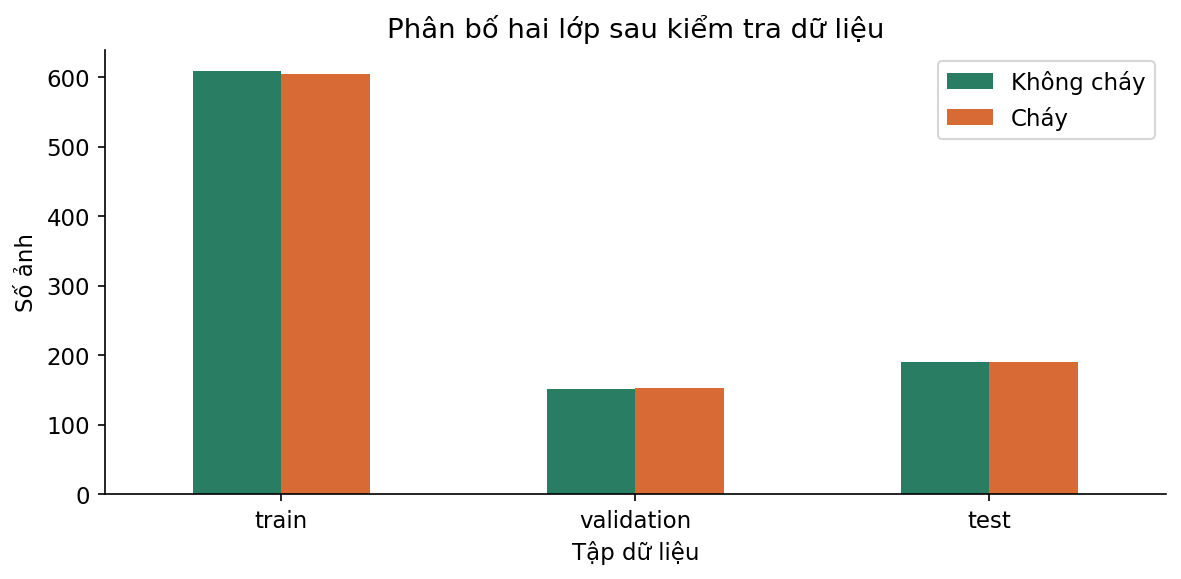

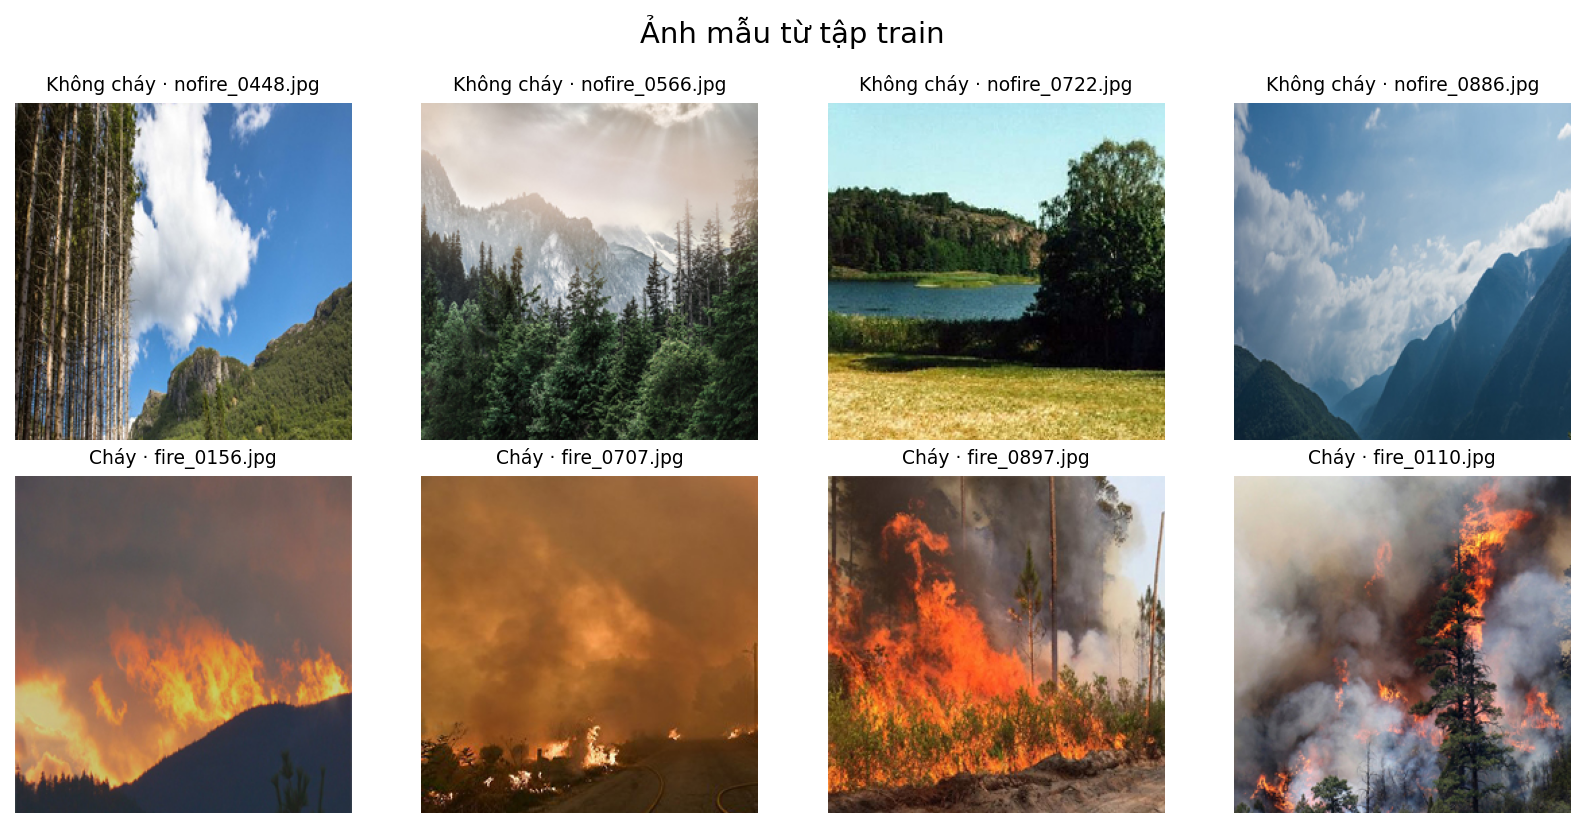

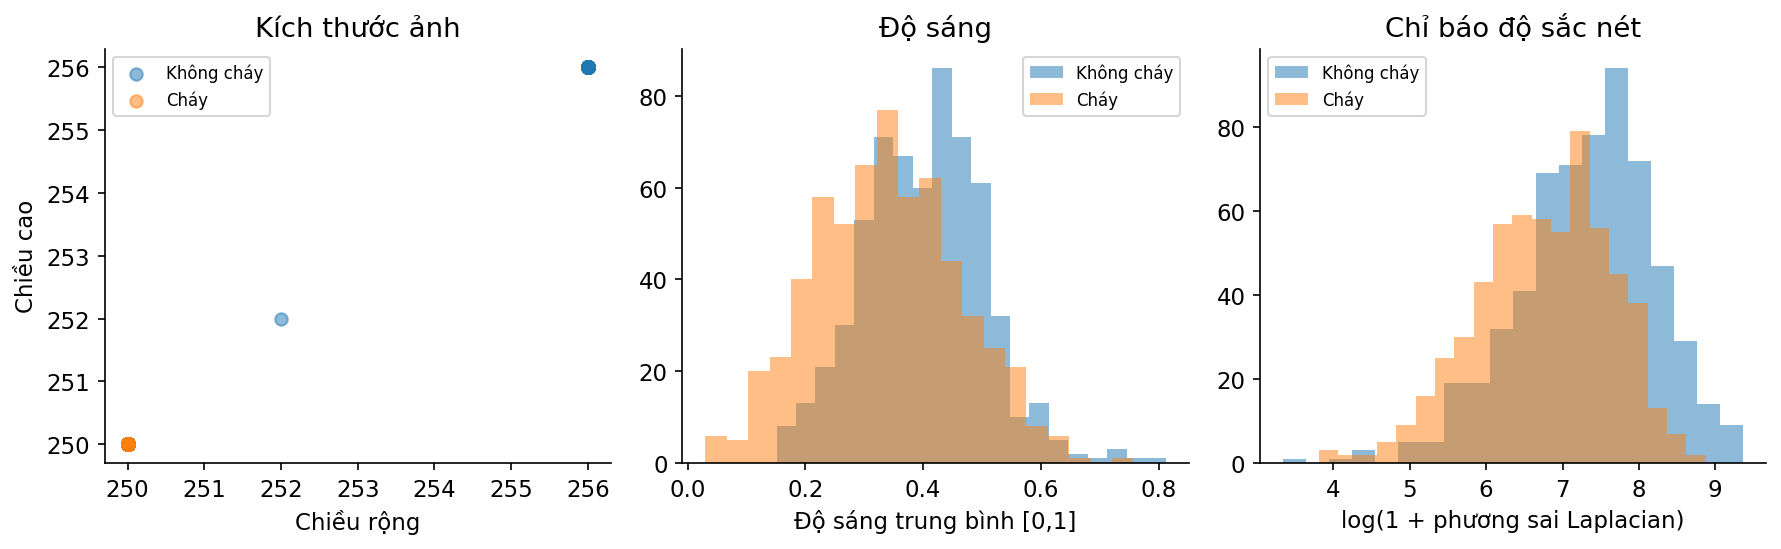

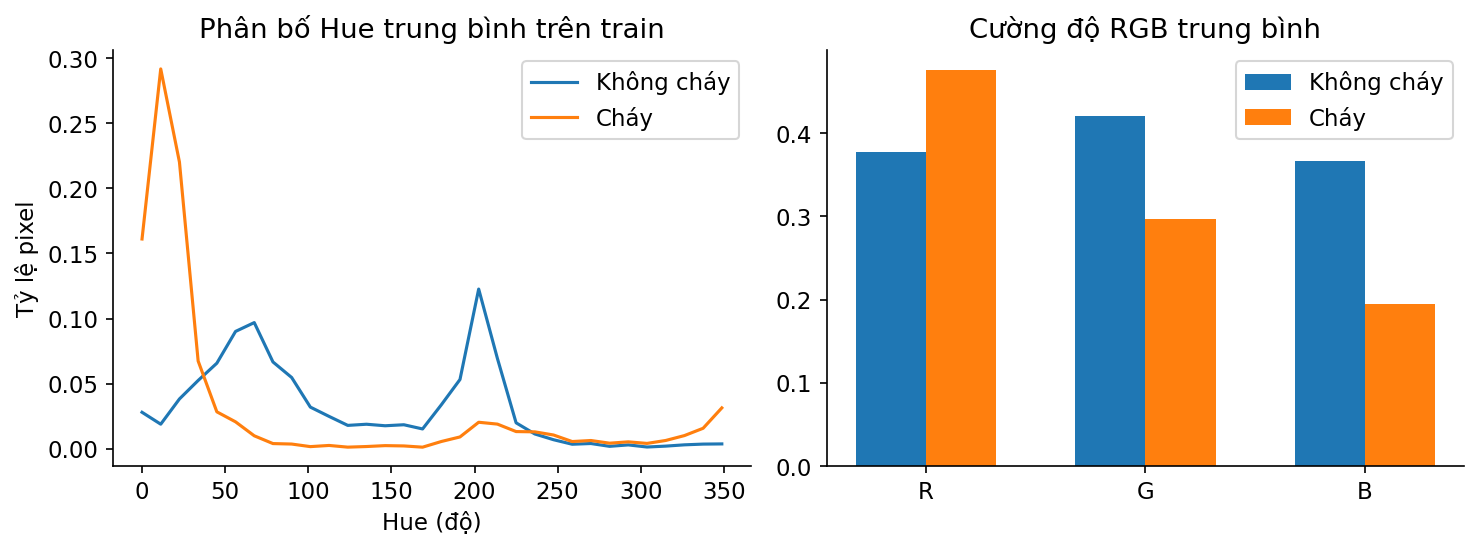

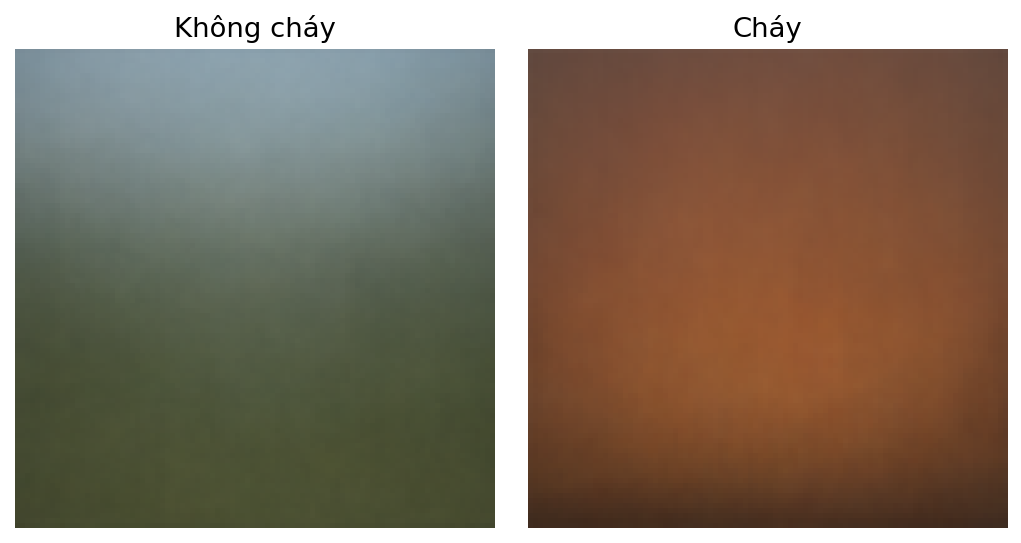

In [8]:
from IPython.display import display, Image as DisplayImage
for f in ['01_class_distribution','02_samples','03_quality','04_color','05_mean_images']:
    display(DisplayImage(filename=str(ROOT/f'reports/figures/{f}.png'),width=900))


## 4. Tiền xử lý và trích đặc trưng
RGB 96×96, chia 255. Histogram HSV gồm 32+16+16=64 chiều. HOG gồm 800 chiều mô tả hướng cạnh cục bộ. Ghép thành 864 chiều, chuẩn hóa và PCA giữ 95% phương sai **trên train**. PCA là phép biến đổi, không phải đặc trưng thứ ba. Không tăng cường ảnh test hoặc dùng SMOTE mặc định.

In [9]:
print('Số đặc trưng:', summary['feature_dimension'])
display(pd.Series(summary['feature_config']))

Số đặc trưng: 864


image_size                 [96, 96]
HSV_bins               [32, 16, 16]
HOG_orientations                  8
HOG_pixels_per_cell        [16, 16]
HOG_cells_per_block          [2, 2]
PCA_variance                   0.95
dtype: object

## 5. Mô hình và thông số
3-fold StratifiedGroupKFold trên train để tìm tham số theo F1 lớp cháy. Cả bốn mô hình dùng chung đầu vào. Sau đó chọn mô hình theo validation F1, hòa điểm thì chọn Recall cao hơn. Không cộng hoặc kết hợp SVM và RF nếu chưa thực nghiệm ensemble.

In [10]:
display(pd.DataFrame(summary['best_params']).T.fillna('—'))
print('Mô hình được chọn:',summary['selected_model'])

,model__C,model__n_neighbors,model__weights,model__kernel,model__max_depth,model__min_samples_leaf
Logistic Regression,1.0,—,—,—,—,—
KNN,—,3,uniform,—,—,—
SVM,10,—,—,rbf,—,—
Random Forest,—,—,—,—,—,1.0


Mô hình được chọn: SVM


## 6. Kết quả và phân tích
Accuracy tính toàn bộ ảnh đúng. Precision lớp cháy là tỷ lệ báo cháy đúng. Recall lớp cháy là tỷ lệ ảnh cháy tìm được. F1 là trung bình điều hòa của Precision và Recall. Ma trận: hàng thật, cột dự đoán; thứ tự Không cháy, Cháy.

,model,cv_f1,cv_f1_std,search_seconds,pca_components,train_accuracy,train_precision,train_recall,train_f1,train_macro_f1,...,validation_precision,validation_recall,validation_f1,validation_macro_f1,test_accuracy,test_precision,test_recall,test_f1,test_macro_f1,predict_ms_per_image
0,Logistic Regression,0.937850,0.010609,4.107148,231,1.000000,1.00000,1.000000,1.000000,1.000000,...,0.934211,0.934211,0.934211,0.933993,0.926316,0.921875,0.931579,0.926702,0.926314,0.022960
1,KNN,0.750450,0.029300,5.734045,231,0.875515,0.97286,0.771523,0.860572,0.874069,...,0.936170,0.578947,0.715447,0.760501,0.744737,0.926606,0.531579,0.675585,0.732587,0.080066
2,SVM,0.936592,0.004640,4.150436,231,1.000000,1.00000,1.000000,1.000000,1.000000,...,0.924051,0.960526,0.941935,0.940562,0.939474,0.928205,0.952632,0.940260,0.939463,0.676806
3,Random Forest,0.883565,0.015740,21.346530,231,1.000000,1.00000,1.000000,1.000000,1.000000,...,0.848101,0.881579,0.864516,0.861312,0.876316,0.886486,0.863158,0.874667,0.876294,0.288499


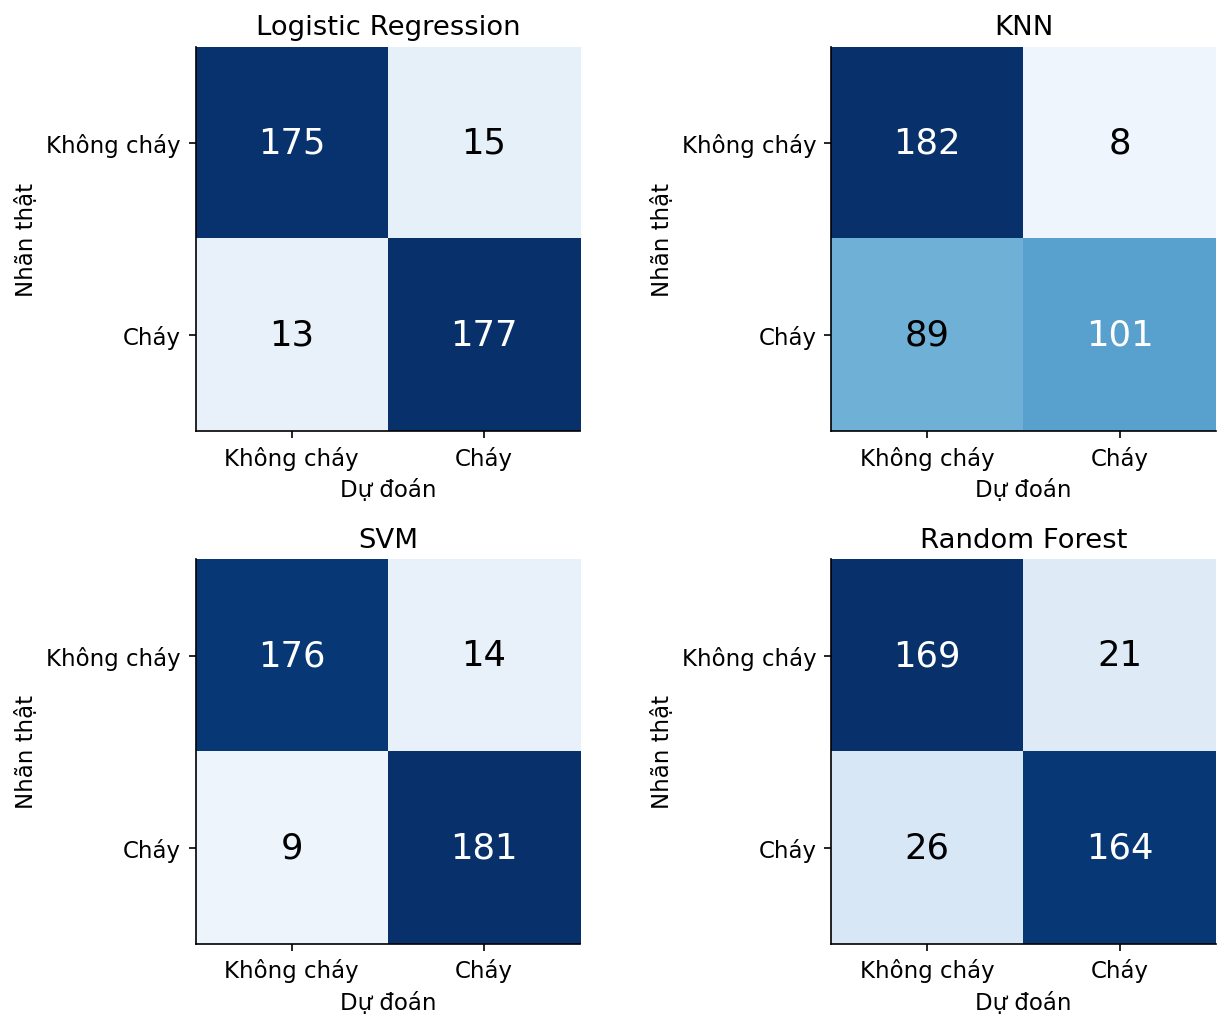

In [11]:
metrics=pd.read_csv(ROOT/'results/model_metrics.csv')
display(metrics)
display(DisplayImage(filename=str(ROOT/'reports/figures/06_confusion_matrices.png'),width=850))

## 7. So sánh mô hình và phân tích lỗi
Xem chênh lệch train/validation cùng đường học. Chênh lệch lớn là dấu hiệu cần xem xét học quá khớp, chưa chứng minh nguyên nhân. Các lỗi ở cuối là ảnh test, chỉ dùng phân tích sau khi đã chốt mô hình.

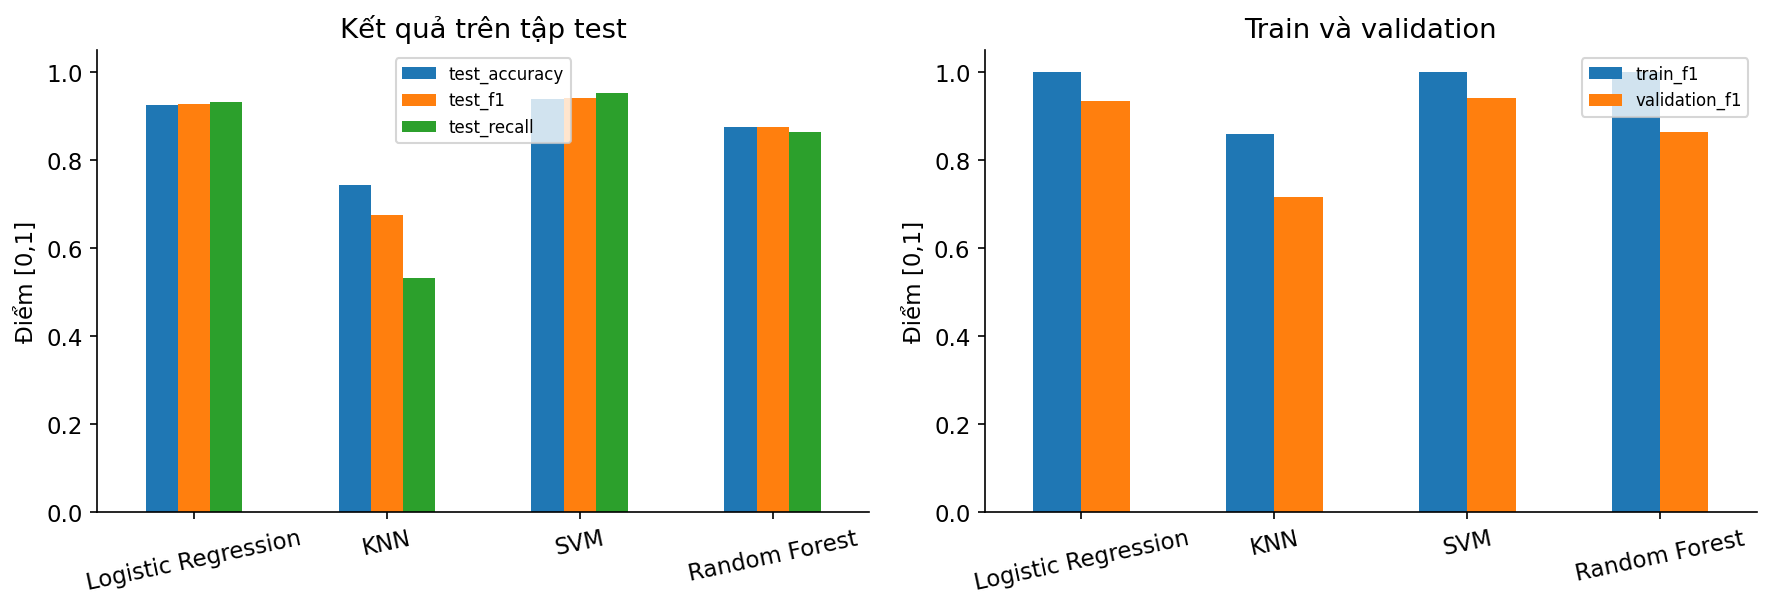

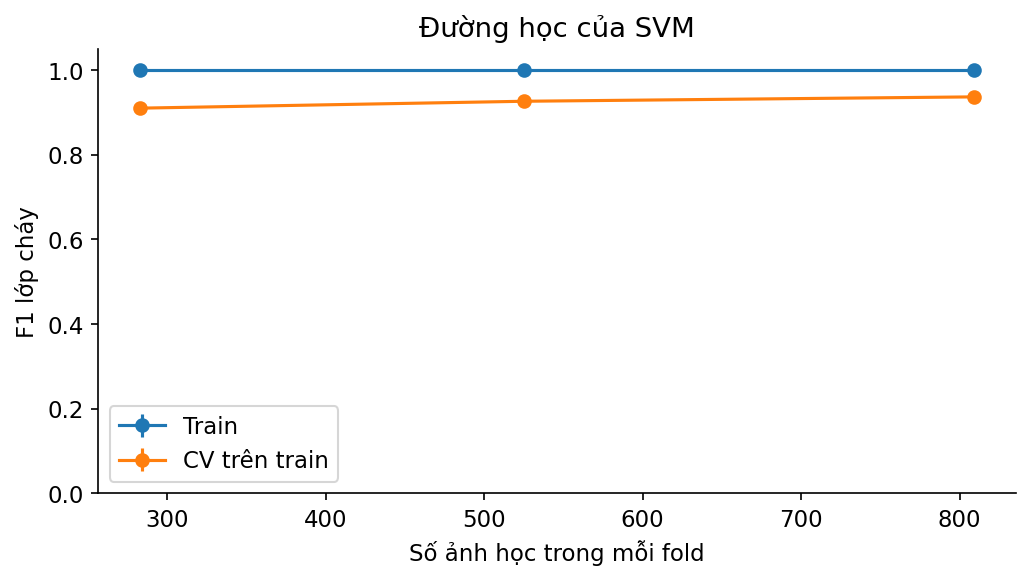

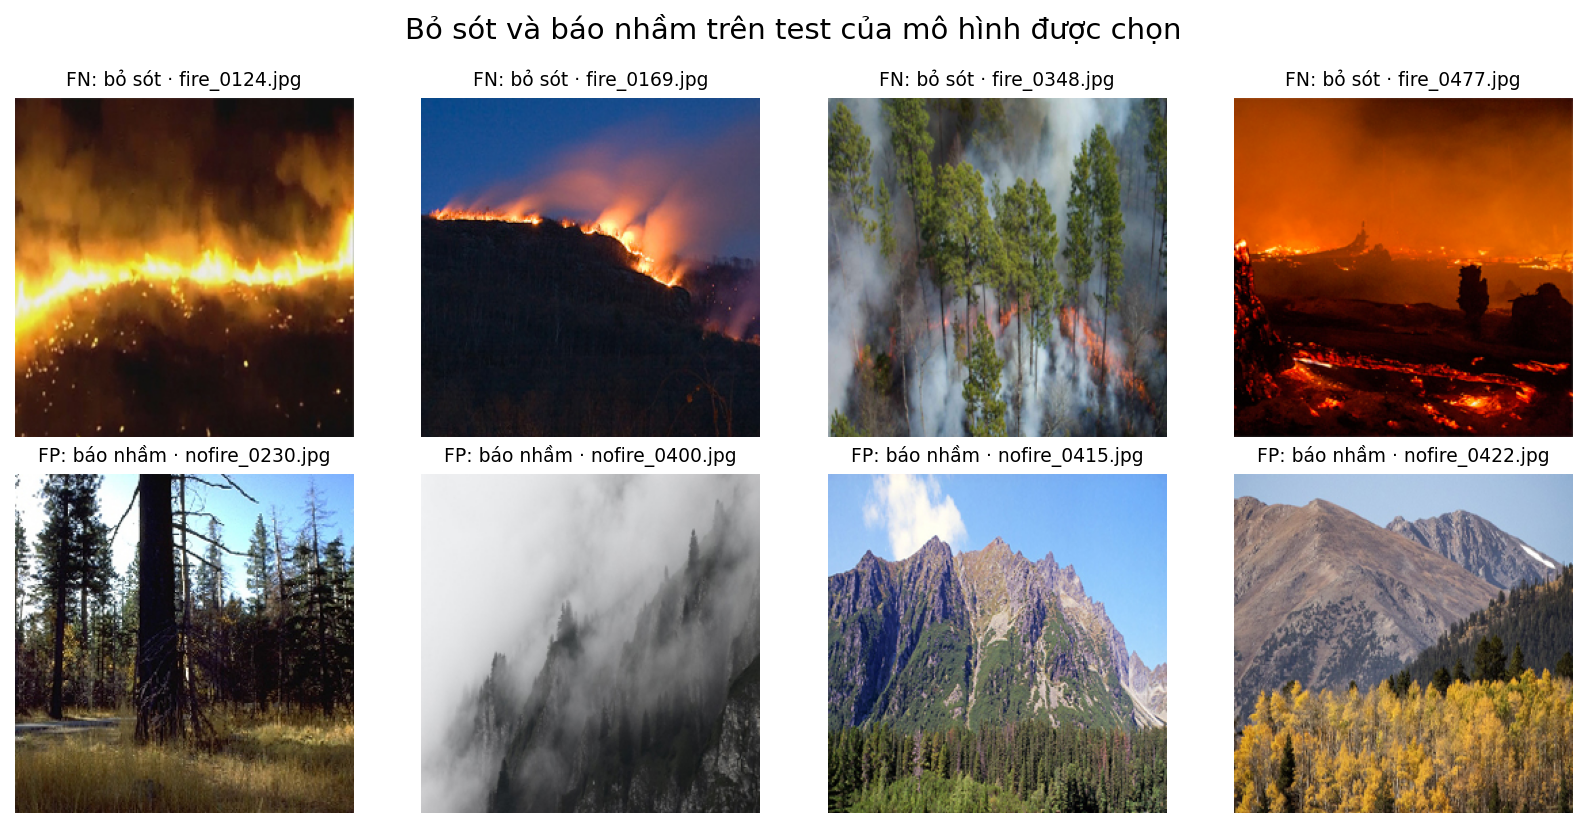

brightness          sharpness      
                   mean count         mean count
error_type                                      
FN: bỏ sót     0.322137     9   559.153188     9
FP: báo nhầm   0.375616    14  1573.231289    14
Đúng           0.370641   357  1686.164570   357

In [12]:
for f in ['07_model_comparison','08_learning_curve','09_errors']:
    display(DisplayImage(filename=str(ROOT/f'reports/figures/{f}.png'),width=900))
display(pd.read_csv(ROOT/'results/error_quality.csv',header=[0,1],index_col=0))

## 8. Kết luận
Chỉ kết luận trong phạm vi dữ liệu và cách chia đã mô tả. Mô hình tốt nhất trên validation có thể không đứng đầu test; cần báo cáo trung thực sự khác biệt này.

In [13]:
chosen=metrics[metrics.model==summary['selected_model']].iloc[0]
print('Mô hình chọn trên validation:',chosen['model'])
print('Test Accuracy:',round(chosen.test_accuracy,4),'F1:',round(chosen.test_f1,4),'Recall:',round(chosen.test_recall,4))
print('Mô hình có test F1 cao nhất (chỉ mô tả):',metrics.loc[metrics.test_f1.idxmax(),'model'])

Mô hình chọn trên validation: SVM
Test Accuracy: 0.9395 F1: 0.9403 Recall: 0.9526
Mô hình có test F1 cao nhất (chỉ mô tả): SVM


## 9. Hướng phát triển
Thu thập ảnh từ camera/địa điểm mới để đánh giá độc lập. Bổ sung ảnh khó và kiểm tra lại nhãn. Thử loại bỏ từng nhóm đặc trưng bằng train/validation. Phân biệt lửa và khói bằng nhãn riêng trước khi mở rộng. Nếu dùng camera thật, cần đánh giá độ trễ toàn bộ và độ ổn định theo video.

## 10. Phụ lục mã và tài liệu
Mã đầy đủ nằm trong notebook này. Kết quả CSV/JSON nằm trong results, mô hình nằm trong models.

- Dataset: https://www.kaggle.com/datasets/alik05/forest-fire-dataset
- Pipeline và rò rỉ dữ liệu: https://scikit-learn.org/stable/common_pitfalls.html
- HOG: https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html

Để lưu kết quả trên Colab, chạy ô cuối rồi tải tệp ZIP trong bảng Files.

In [14]:
import zipfile
bundle=ROOT/'Ket_qua_MayHoc.zip'
with zipfile.ZipFile(bundle,'w',zipfile.ZIP_DEFLATED) as z:
    for folder in ['results','models','reports/figures']:
        for p in (ROOT/folder).rglob('*'):
            if p.is_file() and p.suffix!='.npz': z.write(p,p.relative_to(ROOT))
print('Tệp kết quả:',bundle)


Tệp kết quả: C:\Users\Admin\Desktop\Hosonhaphoc\6-Xử lí Ngôn ngữ Tự nhiên\Doan\MayHoc\Ket_qua_MayHoc.zip
